# VT - Vanguard Total World Stock ETF

In [31]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib

%matplotlib inline

In [32]:
file_path = "VT_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    categorized_df[col] = categorized_df[col].astype('category')

categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2008-06-26,0.383134,0.371755,0.378410,0.374925,0.008330,"(0.38, 0.4]","(0.36, 0.38]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]"
1,2008-06-27,0.417735,0.405422,0.376642,0.373039,0.021524,"(0.4, 0.42]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(0.0182, 0.0364]"
2,2008-06-30,0.423834,0.411633,0.378878,0.373956,0.018044,"(0.42, 0.44]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]"
3,2008-07-01,0.365257,0.362851,0.342444,0.364032,0.055530,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.36, 0.38]","(0.0545, 0.0727]"
4,2008-07-02,0.374496,0.364824,0.356799,0.347692,0.079141,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.34, 0.36]","(0.0727, 0.0909]"


# Clustering

#### K-means

0. date formatting

In [33]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
categorized_df.head()

0    2008-06-26
1    2008-06-27
2    2008-06-30
3    2008-07-01
4    2008-07-02
5    2008-07-03
6    2008-07-07
7    2008-07-08
8    2008-07-09
9    2008-07-10
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1984 entries, 0 to 1983
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1984 non-null   datetime64[ns]
 1   Open             1984 non-null   float64       
 2   High             1984 non-null   float64       
 3   Low              1984 non-null   float64       
 4   Close            1984 non-null   float64       
 5   Volume           1984 non-null   float64       
 6   Open_category    1984 non-null   category      
 7   High_category    1984 non-null   category      
 8   Low_ca

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2008-06-26,0.383134,0.371755,0.378410,0.374925,0.008330,"(0.38, 0.4]","(0.36, 0.38]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]"
1,2008-06-27,0.417735,0.405422,0.376642,0.373039,0.021524,"(0.4, 0.42]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(0.0182, 0.0364]"
2,2008-06-30,0.423834,0.411633,0.378878,0.373956,0.018044,"(0.42, 0.44]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]"
3,2008-07-01,0.365257,0.362851,0.342444,0.364032,0.055530,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.36, 0.38]","(0.0545, 0.0727]"
4,2008-07-02,0.374496,0.364824,0.356799,0.347692,0.079141,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.34, 0.36]","(0.0727, 0.0909]"


1. add features

In [34]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df['Day'] = categorized_df['Date'].dt.day
categorized_df['Day_of_Week'] = categorized_df['Date'].dt.day_name()  # یا .dt.weekday برای مقدار عددی
categorized_df.head(10)

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month,Day,Day_of_Week
0,2008-06-26,0.383134,0.371755,0.378410,0.374925,0.008330,"(0.38, 0.4]","(0.36, 0.38]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]",2008,6,26,Thursday
1,2008-06-27,0.417735,0.405422,0.376642,0.373039,0.021524,"(0.4, 0.42]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(0.0182, 0.0364]",2008,6,27,Friday
2,2008-06-30,0.423834,0.411633,0.378878,0.373956,0.018044,"(0.42, 0.44]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]",2008,6,30,Monday
3,2008-07-01,0.365257,0.362851,0.342444,0.364032,0.055530,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.36, 0.38]","(0.0545, 0.0727]",2008,7,1,Tuesday
4,2008-07-02,0.374496,0.364824,0.356799,0.347692,0.079141,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.34, 0.36]","(0.0727, 0.0909]",2008,7,2,Wednesday
5,2008-07-03,0.357064,0.344538,0.349700,0.350703,0.010386,"(0.34, 0.36]","(0.34, 0.36]","(0.34, 0.36]","(0.34, 0.36]","(-0.002, 0.0182]",2008,7,3,Thursday
6,2008-07-07,0.357300,0.344351,0.343822,0.348425,0.056061,"(0.34, 0.36]","(0.34, 0.36]","(0.34, 0.36]","(0.34, 0.36]","(0.0545, 0.0727]",2008,7,7,Monday
7,2008-07-08,0.342355,0.338860,0.329727,0.350520,0.054512,"(0.34, 0.36]","(0.32, 0.34]","(0.32, 0.34]","(0.34, 0.36]","(0.0364, 0.0545]",2008,7,8,Tuesday
8,2008-07-09,0.371146,0.357973,0.346033,0.337715,0.023990,"(0.36, 0.38]","(0.34, 0.36]","(0.34, 0.36]","(0.32, 0.34]","(0.0182, 0.0364]",2008,7,9,Wednesday
9,2008-07-10,0.346699,0.333076,0.339349,0.336013,0.014245,"(0.34, 0.36]","(0.32, 0.34]","(0.32, 0.34]","(0.32, 0.34]","(-0.002, 0.0182]",2008,7,10,Thursday


3. Selecting the number of clusters</br>
To select the optimal number of clusters, use the Elbow Method:

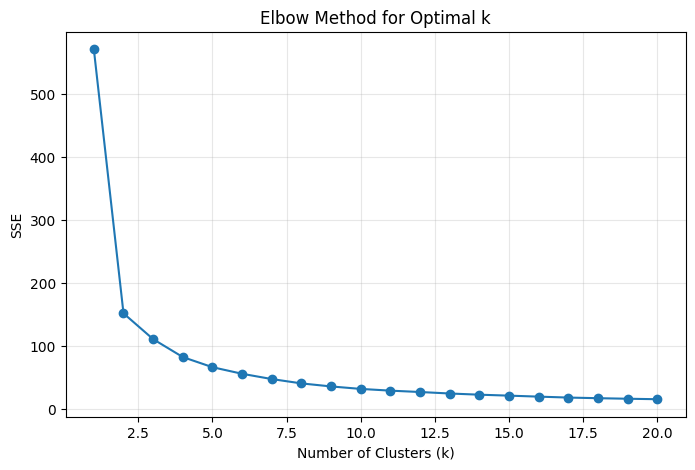

In [35]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

clistering_df = categorized_df.copy()

# Calculate SSE for different values of k
sse = []

# The range of the clusters
k_values = range(1, 21)
# n_init = 20

# hint: n_init and k_values must be equal => x, y
for k in k_values:
    # random_state = seed | n_init = amount of repetition of algorithm
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)  # Explicitly set n_init=10
    kmeans.fit(clistering_df[features])
    sse.append(kmeans.inertia_)

# Draw Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# The optimal number of clusters is at the point where the graph has a significant change (skeletal).


Clustering with K-Means

the choosed option here is k=5

In [36]:
# Running the K-Means algorithm with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
clustering_result = kmeans.fit_predict(clistering_df[features])

# Adding cluster labels to the DataFrame
clistering_df['Cluster'] = clustering_result
clistering_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month,Day,Day_of_Week,Cluster
0,2008-06-26,0.383134,0.371755,0.378410,0.374925,0.008330,"(0.38, 0.4]","(0.36, 0.38]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]",2008,6,26,Thursday,0
1,2008-06-27,0.417735,0.405422,0.376642,0.373039,0.021524,"(0.4, 0.42]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(0.0182, 0.0364]",2008,6,27,Friday,0
2,2008-06-30,0.423834,0.411633,0.378878,0.373956,0.018044,"(0.42, 0.44]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]",2008,6,30,Monday,0
3,2008-07-01,0.365257,0.362851,0.342444,0.364032,0.055530,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.36, 0.38]","(0.0545, 0.0727]",2008,7,1,Tuesday,0
4,2008-07-02,0.374496,0.364824,0.356799,0.347692,0.079141,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.34, 0.36]","(0.0727, 0.0909]",2008,7,2,Wednesday,0


Clustering Visualization

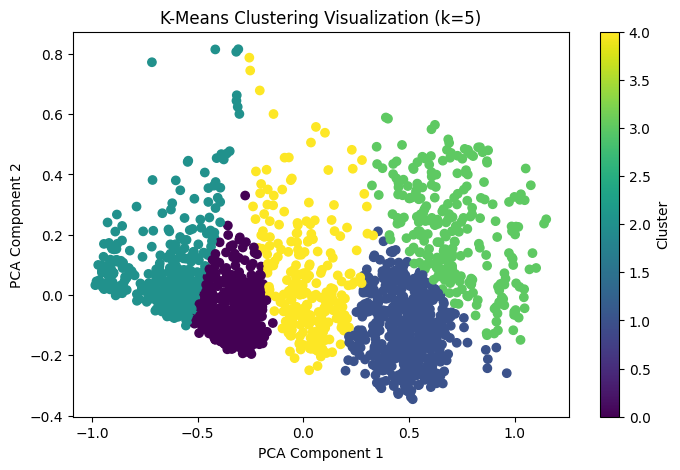

In [37]:
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(clistering_df[features])

plt.figure(figsize=(8, 5))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clistering_df['Cluster'], cmap='viridis', marker='o')
plt.title("K-Means Clustering Visualization (k=5)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()


Dimensionality reduction with PCA: </br>
o The data was reduced from a multidimensional space (5 features) to a two-dimensional space to visually display the clusters.


Graph analysis:</br>
1. Data dispersion:</br>
    o The data is scattered in a two-dimensional space (reduced with PCA).</br>
    o Each point represents a sample of your data (stock data).</br>


2. Cluster coloring:</br>
    o Points with different colors belong to different clusters (based on the cluster label ClusterClusterCluster).</br>


3. Cluster structure:</br>
    o The clusters are generally separate from each other, although some clusters (e.g. green and light blue) may overlap slightly.</br>
    o This indicates that the algorithm was able to identify patterns in the data.


Interpretation of Results:</br>
• The identified clusters can represent different groups in the stock data:</br>
    o Example: stocks with similar price behavior or volume.</br>
    o Clusters can be used to analyze market behavior, identify trading patterns, or segment data based on similar characteristics.

Examining the contribution of Volume to PCA components

In [38]:
pca_components = pd.DataFrame(pca.components_, columns=features)
print(pca_components)

       Open      High       Low     Close    Volume
0  0.475542  0.483081  0.476259  0.477337  0.292950
1 -0.144798 -0.143491 -0.150359 -0.147288  0.956108


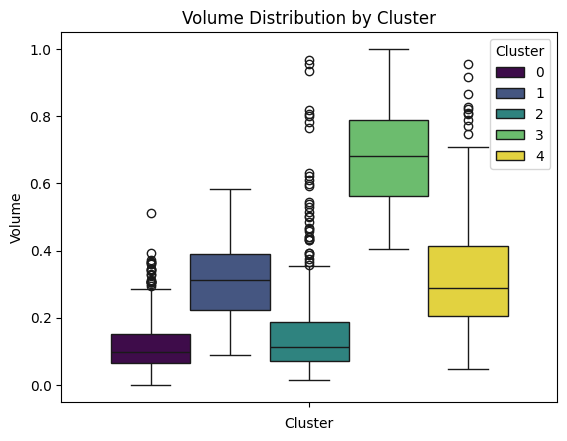

In [39]:
sns.boxplot(hue='Cluster', y='Volume', data=clistering_df, palette='viridis')
plt.title("Volume Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Volume")
plt.show()


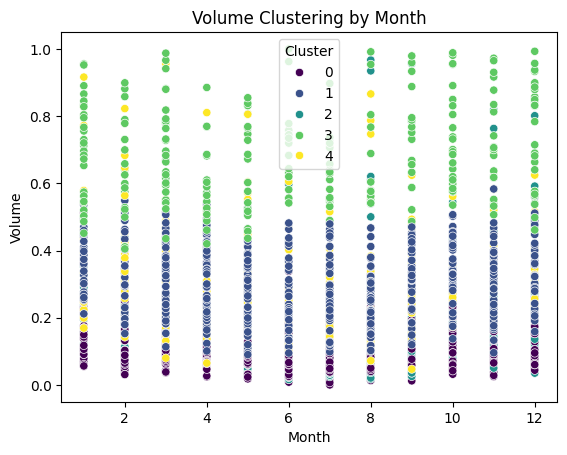

In [40]:
# Based on Volume

sns.scatterplot(
    x='Month', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Month")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

Identifying Clustering Patterns:


Cluster 4 (yellow):</br>
This cluster appears to contain data with high trading volume (Volume close to 1).</br>
This data may represent days or stocks with high trading activity.

Cluster 0 (purple):</br>
This cluster contains data with low trading volume (Volume close to 0).</br>
This cluster likely represents days or stocks with low trading activity.

Cluster 1, Cluster 2, and Cluster 3 (middle colors):</br>
These clusters cover data with medium trading volume.</br>
These clusters may be formed based on fluctuations or changes in trading volume in different months of the year.

Different colors in clusters (top and bottom):</br>
Each color represents a cluster.

Vertical position (Volume):
The position of the points on the y-axis is determined by the amount of trading volume (Volume).</br>
Higher points have more trading volume.</br>
Lower points have less trading volume.

Why are the points of a cluster visible at the top and bottom?</br>
Intermediate clusters (such as Cluster 1, Cluster 2, or Cluster 3) may contain points from the high </br>
    (volume close to the higher average) and low (volume close to the lower average) regions on the Volume scale.</br>
This occurs due to the combination of other clustering features (such as Open, High, and Close).

If a cluster contains data with a different combination of price features (Open, Close, High, Low)</br>
    but the Volume value fluctuates, the points of that cluster may be visible at the top and bottom of the chart.

Each circle on the chart represents one trading day.</br>
The number of circles in each column (month) should equal the number of trading days in that month.</br>
For example: if a month has 22 trading days, there are 22 circles for that month on the chart.

In [41]:
days_per_year_month = clistering_df.groupby(['Year', 'Month']).size()
print(days_per_year_month)

Year  Month
2008  6         3
      7        22
      8        21
      9        21
      10       14
               ..
2017  1        19
      2        12
      3        17
      4        16
      5        16
Length: 104, dtype: int64


In [42]:
print(clistering_df['Year'].unique())

[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017]


In [43]:
days_per_month = clistering_df.groupby('Month').size()
print(days_per_month)

Month
1     139
2     133
3     162
4     156
5     182
6     168
7     186
8     189
9     181
10    180
11    161
12    147
dtype: int64


In [44]:
cluster_by_month = clistering_df.groupby(['Month', 'Cluster']).size().unstack()
print(cluster_by_month)

Cluster   0   1   2   3   4
Month                      
1        44  31  14  30  20
2        37  31  19  18  28
3        46  46  13  31  26
4        56  55   1  18  26
5        41  57  39  21  24
6        42  42  47  16  21
7        62  40  42  19  23
8        54  44  55  13  23
9        37  40  58  19  27
10       48  51  46  23  12
11       47  52  35  23   4
12       37  35  35  28  12


Observations:


Cluster 0 (low trading volume):</br>
Has more data in months 5 and 8 than in other months (47 and 41 samples).</br>
It is generally present in all months and seems to be a stable cluster.


Cluster 1 (very low trading volume):</br>
This cluster is very prominent in month 7 (62 samples).</br>
It also has a relatively large number of data in months 4 and 8 (52 and 52 samples).


Cluster 2 (medium trading volume):</br>
This cluster is most numerous in months 6, 7 and 9 (47, 42 and 53 samples).</br>
This cluster represents medium-volume data that is present variably across months.


Cluster 3 (above-average trading volume):</br>
Has more data in months 3 and 4 (28 and 27 samples).</br>
Fewer numbers are observed in months 11 and 12 (10 and 18 samples).


Cluster 4 (high trading volume):</br>
It has the largest number of data in month 4 (38 samples).</br>
It has the lowest number in month 8 (11 samples).


Conclusions from the cluster distribution:</br>
Clusters 0 and Cluster 1 are widely and consistently observed in all months and represent low volume data.</br>
Clusters with medium volume (Cluster 2 and Cluster 3) are more prominent in certain months such as 6 and 7.</br>
Cluster 4, which represents high trading volume, is most prominent in month 4 and less present in other months.

In [45]:
cluster_means = clistering_df.groupby('Cluster')['Volume'].mean()
print(cluster_means)


Cluster
0    0.116997
1    0.310463
2    0.160068
3    0.688567
4    0.328193
Name: Volume, dtype: float64


Observations:

Cluster 0:</br>
The average trading volume in this cluster is around 0.39.</br>
This cluster represents data with trading volume close to the low average level.

Cluster 1:</br>
It has the lowest average trading volume (0.15).</br>
This cluster corresponds to data with very low trading activity.

Cluster 2:</br>
Its average trading volume is 0.20 and represents data with slightly higher volume than Cluster 1.

Cluster 3:</br>
Its average trading volume is 0.47 and represents data with higher volume than the average.

Cluster 4:</br>
It has the highest average trading volume (0.74).</br>
This cluster corresponds to days or stocks with very high trading activity.


Conclusion of average trading volume:</br>
The clusters are well separated from each other in terms of trading volume:</br>
Cluster 1 and Cluster 2 have low and relatively low trading volumes.</br>
Clusters 3 and 4 represent above-average and very high trading volumes.

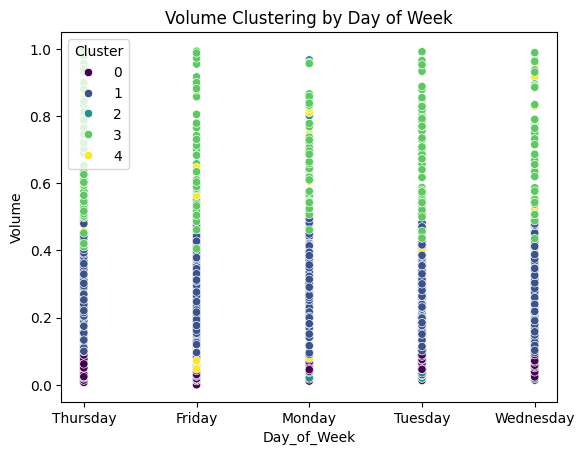

In [46]:
sns.scatterplot(
    x='Day_of_Week', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Day of Week")
plt.xlabel("Day_of_Week")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

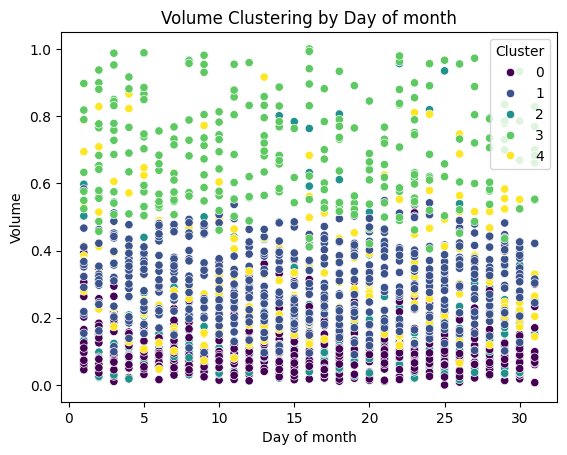

In [47]:
sns.scatterplot(
    x='Day', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Day of month")
plt.xlabel("Day of month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

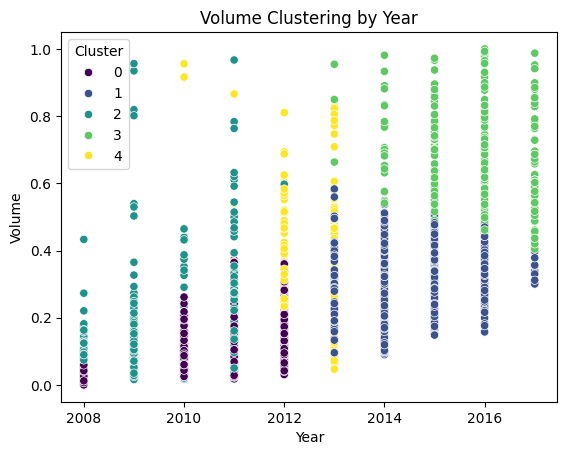

In [48]:
sns.scatterplot(
    x='Year', y='Volume', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Volume Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

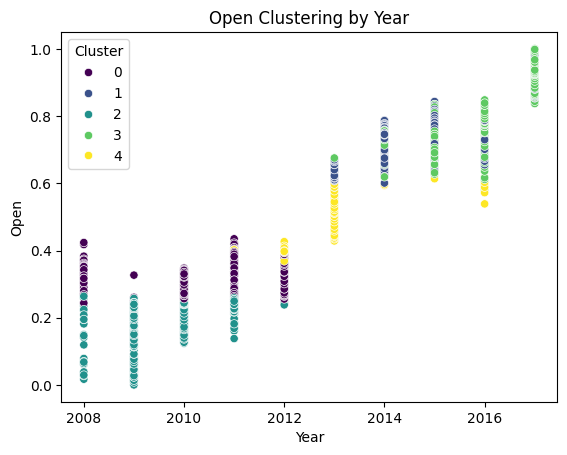

In [49]:
sns.scatterplot(
    x='Year', y='Open', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("Open Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Open")
plt.legend(title="Cluster")
plt.show()

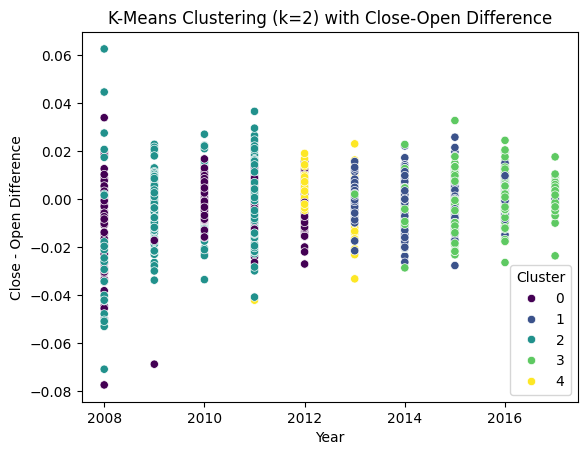

In [50]:
# Create a new column for the difference between Close and Open
clistering_df['Close_Open_Diff'] = clistering_df['Close'] - clistering_df['Open']

# Scatter plot with the difference as y-axis
sns.scatterplot(
    x='Year', y='Close_Open_Diff', hue='Cluster', data=clistering_df, palette='viridis'
)
plt.title("K-Means Clustering (k=2) with Close-Open Difference")
plt.xlabel("Year")
plt.ylabel("Close - Open Difference")
plt.legend(title="Cluster")
plt.show()
